# Phase 2 Solidification: Multi-class Regulatory Classification & Cross-Cell-Type Generalization

In this notebook, we solidify the Phase 2 deep learning baselines by:
1. Extending classification to **multi-class classification** with three target categories:
   * **Background (0)**
   * **Promoter-like Signature PLS (1)**
   * **distal/proximal Enhancer-like Signature dELS/pELS (2)**
2. Generating cell-type specific annotations for **K562** and **GM12878** using ENCODE representative candidate cis-Regulatory Elements (cCREs).
3. Training an `AttentionCNN` model on **K562** Chromosome 22 sequence data.
4. Evaluating the cross-cell-type generalization performance of the K562-trained model directly on **GM12878** sequences.
5. Visualizing model predictions and computing sequence attribution maps (saliency maps) for regulatory elements.

## 1. Environment Setup & Imports

In [1]:
!git clone https://github.com/PxA-Labs/interpretable-regulatory-genomics.git


fatal: destination path 'interpretable-regulatory-genomics' already exists and is not an empty directory.


In [2]:
import os
import sys

# Dynamic recursive search for the 'src/data' directory
def find_repo_root(start_dir):
    for root, dirs, files in os.walk(start_dir):
        if "src" in dirs:
            if os.path.exists(os.path.join(root, "src", "data")):
                return os.path.abspath(root)
    return None

repo_root = find_repo_root(".")
if not repo_root:
    repo_root = find_repo_root("..")

if repo_root:
    print(f"Located repository root containing 'src' at: {repo_root}")
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
else:
    print("WARNING: Could not find 'src/data' folder anywhere in current or parent directories!")
    print(f"Current working directory: {os.getcwd()}")
    print("Files in current directory:", os.listdir("."))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from src.data.download import download_biosample_ccres, download_hg38_chromosome
from src.data.parse_encode import parse_and_resize_ccres
from src.data.sequence_extractor import extract_sequences
from src.data.negative_sampling import build_negative_dataset
from src.models.cnn import ShallowCNN, DeepCNN, AttentionCNN
from src.models.train_nn import PyTorchModelWrapper
from src.interpret.cnn_interpretability import compute_attribution, plot_sequence_attribution
from src.data.dataset import sequence_to_onehot

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Located repository root containing 'src' at: /kaggle/working/interpretable-regulatory-genomics
Using device: cuda


## 2. Cell-Type Specific Annotation & Sequence Curation Pipeline

We download cell-type specific annotations for K562 and GM12878 from ENCODE, map coordinates, and extract raw FASTA sequence ranges on Chromosome 22.

In [3]:
raw_dir = "../data/raw"
ref_dir = "../data/reference"
proc_dir = "../data/processed"

os.makedirs(raw_dir, exist_ok=True)
os.makedirs(ref_dir, exist_ok=True)
os.makedirs(proc_dir, exist_ok=True)

# 1. Download chr22 fasta and cell-type BED annotation sheets
print("Downloading files...")
chr22_fasta = os.path.join(ref_dir, "chr22.fa.gz")
if not os.path.exists(chr22_fasta):
    download_hg38_chromosome("chr22", output_dir=ref_dir)
else:
    print("chr22.fa.gz already exists.")

k562_bed_raw = os.path.join(raw_dir, "ENCFF464BRU.bed.gz")
if not os.path.exists(k562_bed_raw):
    download_biosample_ccres("K562", output_dir=raw_dir)
else:
    print("K562 raw BED already exists.")

gm12878_bed_raw = os.path.join(raw_dir, "ENCFF590IMH.bed.gz")
if not os.path.exists(gm12878_bed_raw):
    download_biosample_ccres("GM12878", output_dir=raw_dir)
else:
    print("GM12878 raw BED already exists.")

Download complete.
Download complete.
Download complete.


In [4]:
# 2. Parse and resize annotations (focusing on chromosome 22 for fast exploration)
print("Parsing cCRE annotations...")
k562_parsed = os.path.join(proc_dir, "k562_chr22.bed")
gm12878_parsed = os.path.join(proc_dir, "gm12878_chr22.bed")

parse_and_resize_ccres(
    input_path=k562_bed_raw,
    output_path=k562_parsed,
    element_types=["PLS", "dELS", "pELS"],
    chromosomes=["chr22"],
    target_length=1000
)

parse_and_resize_ccres(
    input_path=gm12878_bed_raw,
    output_path=gm12878_parsed,
    element_types=["PLS", "dELS", "pELS"],
    chromosomes=["chr22"],
    target_length=1000
)

Parsing cCRE annotations...
Parsing cCRE annotations from ../data/raw/ENCFF464BRU.bed.gz...
Loaded 926535 initial regions.
Filtered by chromosomes. Remaining: 16784
Filtered by element types ['PLS', 'dELS', 'pELS']. Remaining: 1279
Resizing regions to fixed length of 1000 bp...
Filtered out regions with invalid coordinates. Remaining: 1279
Processed BED file saved to ../data/processed/k562_chr22.bed (Total regions: 1279).
Parsing cCRE annotations from ../data/raw/ENCFF590IMH.bed.gz...
Loaded 926535 initial regions.
Filtered by chromosomes. Remaining: 16784
Filtered by element types ['PLS', 'dELS', 'pELS']. Remaining: 1708
Resizing regions to fixed length of 1000 bp...
Filtered out regions with invalid coordinates. Remaining: 1708
Processed BED file saved to ../data/processed/gm12878_chr22.bed (Total regions: 1708).


'../data/processed/gm12878_chr22.bed'

In [5]:
# 3. Extract DNA sequences from reference FASTA
print("Extracting positive sequences...")
k562_pos_tsv = os.path.join(proc_dir, "k562_chr22_pos.tsv")
gm12878_pos_tsv = os.path.join(proc_dir, "gm12878_chr22_pos.tsv")

extract_sequences(
    bed_path=k562_parsed,
    fasta_source=chr22_fasta,
    output_path=k562_pos_tsv
)

extract_sequences(
    bed_path=gm12878_parsed,
    fasta_source=chr22_fasta,
    output_path=gm12878_pos_tsv
)

Extracting positive sequences...
Reading BED coordinates from ../data/processed/k562_chr22.bed...
Total input regions: 1,279
Loading chromosome sequence from ../data/reference/chr22.fa.gz...
Loaded sequence of length 50,818,468 bp.
Sequence extraction complete.
  Extracted regions: 1,279
  Skipped (out of bounds): 0
  Skipped (high N-base fraction): 0
Saved extracted sequences to ../data/processed/k562_chr22_pos.tsv.
Reading BED coordinates from ../data/processed/gm12878_chr22.bed...
Total input regions: 1,708
Loading chromosome sequence from ../data/reference/chr22.fa.gz...
Loaded sequence of length 50,818,468 bp.
Sequence extraction complete.
  Extracted regions: 1,707
  Skipped (out of bounds): 0
  Skipped (high N-base fraction): 1
Saved extracted sequences to ../data/processed/gm12878_chr22_pos.tsv.


'../data/processed/gm12878_chr22_pos.tsv'

In [6]:
# 4. Generate GC-matched background negatives and map labels:
# PLS -> 1
# dELS / pELS -> 2
# Non-regulatory (negative background) -> 0
print("Generating negative sequences and mapping multiclass labels...")
k562_final_tsv = os.path.join(proc_dir, "k562_chr22_multiclass.tsv")
gm12878_final_tsv = os.path.join(proc_dir, "gm12878_chr22_multiclass.tsv")

build_negative_dataset(
    pos_tsv_path=k562_pos_tsv,
    fasta_source=chr22_fasta,
    output_path=k562_final_tsv,
    target_length=1000,
    strategy="gc_matched",
    multiclass=True
)

build_negative_dataset(
    pos_tsv_path=gm12878_pos_tsv,
    fasta_source=chr22_fasta,
    output_path=gm12878_final_tsv,
    target_length=1000,
    strategy="gc_matched",
    multiclass=True
)

Generating negative sequences and mapping multiclass labels...
Loading positive regions with sequences from ../data/processed/k562_chr22_pos.tsv...
Loading chromosome sequence from ../data/reference/chr22.fa.gz...
Loaded sequence of length 50,818,468 bp.
Sampling negatives for chromosome chr22 using strategy 'gc_matched'...
Target negative bin counts for chr22: {11: 270, 12: 229, 10: 206, 13: 188, 9: 134, 14: 128, 8: 65, 15: 48, 7: 10, 16: 1}
Sampled 1279 / 1279 negatives for chr22 (attempts: 100631).
Saved combined positive & negative dataset to ../data/processed/k562_chr22_multiclass.tsv (Total regions: 2,558).
Loading positive regions with sequences from ../data/processed/gm12878_chr22_pos.tsv...
Loading chromosome sequence from ../data/reference/chr22.fa.gz...
Loaded sequence of length 50,818,468 bp.
Sampling negatives for chromosome chr22 using strategy 'gc_matched'...
Target negative bin counts for chr22: {11: 374, 10: 328, 12: 269, 9: 242, 13: 183, 8: 132, 14: 104, 7: 37, 15: 34

'../data/processed/gm12878_chr22_multiclass.tsv'

## 3. Data Exploration & Distribution Analysis

=== K562 Dataset Label Distribution ===
label
0    1279
2     945
1     334
Name: count, dtype: int64

=== GM12878 Dataset Label Distribution ===
label
0    1707
2    1398
1     309
Name: count, dtype: int64


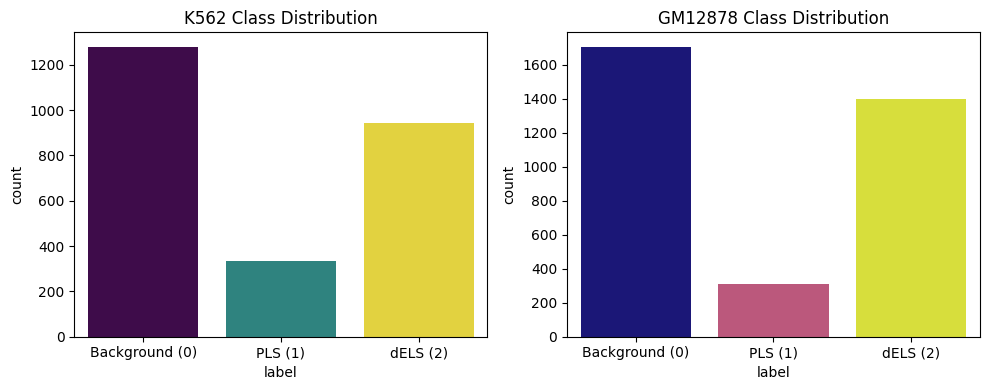

In [7]:
k562_data = pd.read_csv(k562_final_tsv, sep="\t")
gm12878_data = pd.read_csv(gm12878_final_tsv, sep="\t")

print("=== K562 Dataset Label Distribution ===")
print(k562_data["label"].value_counts())
print("\n=== GM12878 Dataset Label Distribution ===")
print(gm12878_data["label"].value_counts())

# Plot class balance comparison
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(data=k562_data, x="label", hue="label", legend=False, palette="viridis")
plt.title("K562 Class Distribution")
plt.xticks([0, 1, 2], ["Background (0)", "PLS (1)", "dELS (2)"])

plt.subplot(1, 2, 2)
sns.countplot(data=gm12878_data, x="label", hue="label", legend=False, palette="plasma")
plt.title("GM12878 Class Distribution")
plt.xticks([0, 1, 2], ["Background (0)", "PLS (1)", "dELS (2)"])

plt.tight_layout()
plt.show()

## 4. Model Training on K562 (3-Class Classification)

We train the `AttentionCNN` model architecture to perform 3-class classification directly on K562 data. Early stopping and Plateau learning rate schedules are managed automatically by the wrapper.

In [8]:
X_train = k562_data["sequence"].values
y_train = k562_data["label"].values

X_test = gm12878_data["sequence"].values
y_test = gm12878_data["label"].values

# Setup the multiclass model wrapper (num_classes=3)
model_params = {
    "sequence_length": 1000,
    "n_heads": 4,
    "dropout_rate": 0.3
}

wrapper = PyTorchModelWrapper(
    model_class=AttentionCNN,
    model_params=model_params,
    epochs=12,
    batch_size=64,
    lr=0.001,
    weight_decay=1e-5,
    num_classes=3,
    val_split=0.15,
    patience=4,
    random_state=42,
    device=device
)

print("Training the AttentionCNN model...")
wrapper.fit(X_train, y_train)

Training the AttentionCNN model...
Training on device: cuda
Epoch 01/12 | Train Loss: 1.0702 | Val Loss: 1.0522 | Val Acc: 0.4909
Epoch 02/12 | Train Loss: 1.0095 | Val Loss: 1.0345 | Val Acc: 0.5274
Epoch 03/12 | Train Loss: 0.9807 | Val Loss: 0.9755 | Val Acc: 0.5640
Epoch 04/12 | Train Loss: 0.9495 | Val Loss: 0.8881 | Val Acc: 0.6057
Epoch 05/12 | Train Loss: 0.9131 | Val Loss: 0.8794 | Val Acc: 0.5953
Epoch 06/12 | Train Loss: 0.8846 | Val Loss: 0.8756 | Val Acc: 0.5666
Epoch 07/12 | Train Loss: 0.8424 | Val Loss: 0.8339 | Val Acc: 0.5561
Epoch 08/12 | Train Loss: 0.8133 | Val Loss: 0.7797 | Val Acc: 0.5901
Epoch 09/12 | Train Loss: 0.7834 | Val Loss: 0.8049 | Val Acc: 0.6188
Epoch 10/12 | Train Loss: 0.7316 | Val Loss: 0.7590 | Val Acc: 0.6371
Epoch 11/12 | Train Loss: 0.7044 | Val Loss: 0.7685 | Val Acc: 0.6292
Epoch 12/12 | Train Loss: 0.6568 | Val Loss: 0.9075 | Val Acc: 0.6110
Loaded best validation model (Loss: 0.7590).


## 5. Inner-Cell-Type Evaluation (K562 Validation Set)

Evaluate model quality and classification report parameters on the K562 dataset.

In [9]:
k562_preds = wrapper.predict(X_train)

print("=== K562 Classification Report ===")
print(classification_report(
    y_train, 
    k562_preds, 
    target_names=["Background (0)", "PLS (1)", "dELS (2)"]
))

=== K562 Classification Report ===
                precision    recall  f1-score   support

Background (0)       0.78      0.86      0.82      1279
       PLS (1)       0.41      0.38      0.40       334
      dELS (2)       0.67      0.59      0.63       945

      accuracy                           0.70      2558
     macro avg       0.62      0.61      0.61      2558
  weighted avg       0.69      0.70      0.69      2558



## 6. Cross-Cell-Type Generalization (K562 $\rightarrow$ GM12878)

We evaluate how well the model trained on K562 generalizes to sequences from GM12878, showcasing the network's ability to extract universal, cell-type invariant features of enhancers and promoters.

In [10]:
gm_preds = wrapper.predict(X_test)
gm_probs = wrapper.predict_proba(X_test)

print("=== GM12878 Cross-Cell-Type Generalization Report ===")
print(classification_report(
    y_test, 
    gm_preds, 
    target_names=["Background (0)", "PLS (1)", "dELS (2)"]
))

acc = accuracy_score(y_test, gm_preds)
print(f"Cross-cell-type Accuracy: {acc:.4f}")

=== GM12878 Cross-Cell-Type Generalization Report ===
                precision    recall  f1-score   support

Background (0)       0.64      0.73      0.68      1707
       PLS (1)       0.37      0.31      0.34       309
      dELS (2)       0.54      0.47      0.50      1398

      accuracy                           0.59      3414
     macro avg       0.52      0.50      0.51      3414
  weighted avg       0.58      0.59      0.58      3414

Cross-cell-type Accuracy: 0.5855


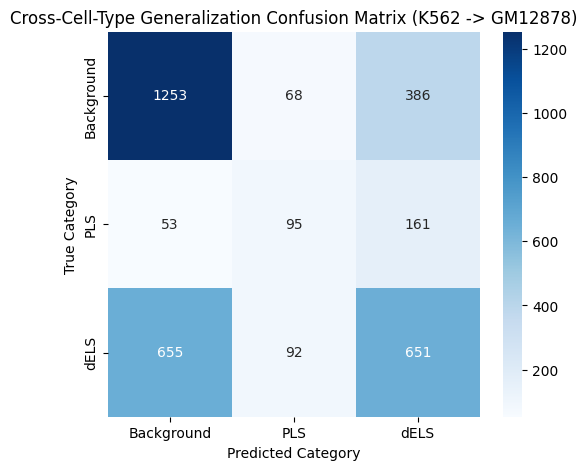

In [11]:
# Plot the Confusion Matrix
cm = confusion_matrix(y_test, gm_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues",
    xticklabels=["Background", "PLS", "dELS"], 
    yticklabels=["Background", "PLS", "dELS"]
)
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.title("Cross-Cell-Type Generalization Confusion Matrix (K562 -> GM12878)")
plt.show()

## 7. Model Interpretation via Saliency Maps

We extract sequence attribution maps (Saliency) for a Promoter-like Element (PLS) and an Enhancer-like Element (dELS) to visualize which motifs shape model predictions.

Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Saved sequence attribution logo plot to ../data/processed/pls_saliency_notebook.png
Saved sequence attribution logo plot to ../data/processed/dels_saliency_notebook.png

=== Promoter-like Signature (PLS) Attribution Logo (Center 100bp) ===


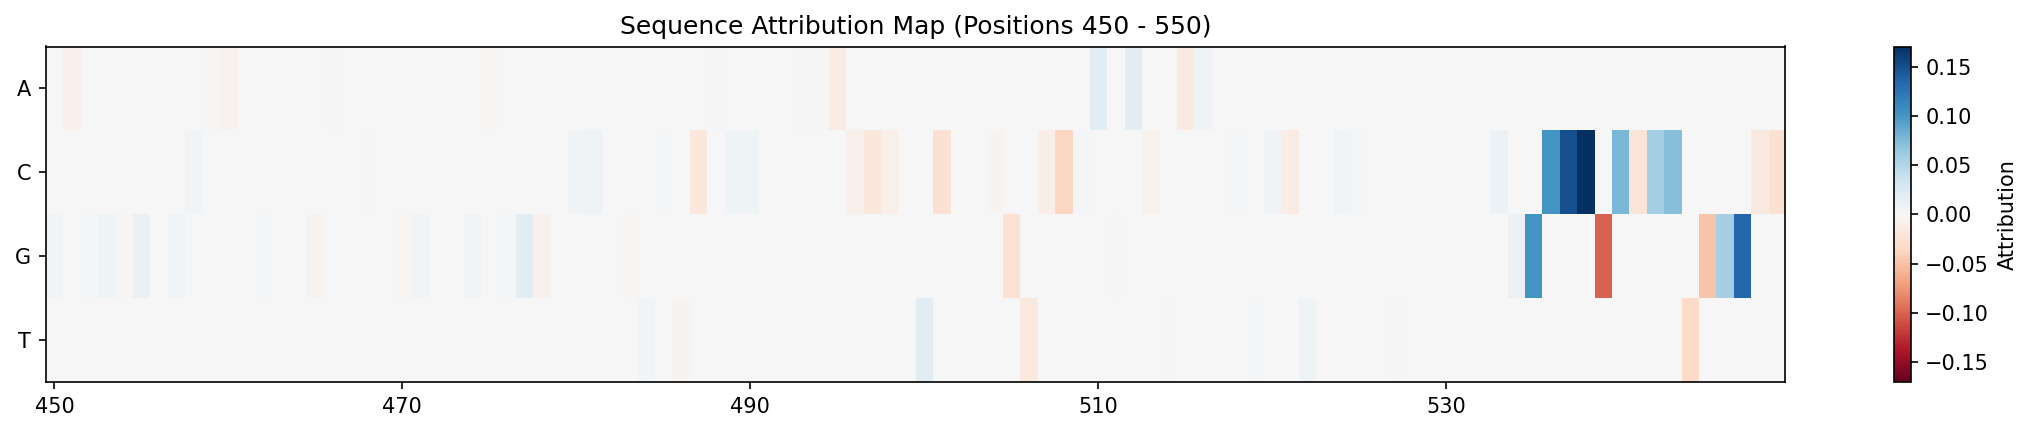


=== distal Enhancer-like Signature (dELS) Attribution Logo (Center 100bp) ===


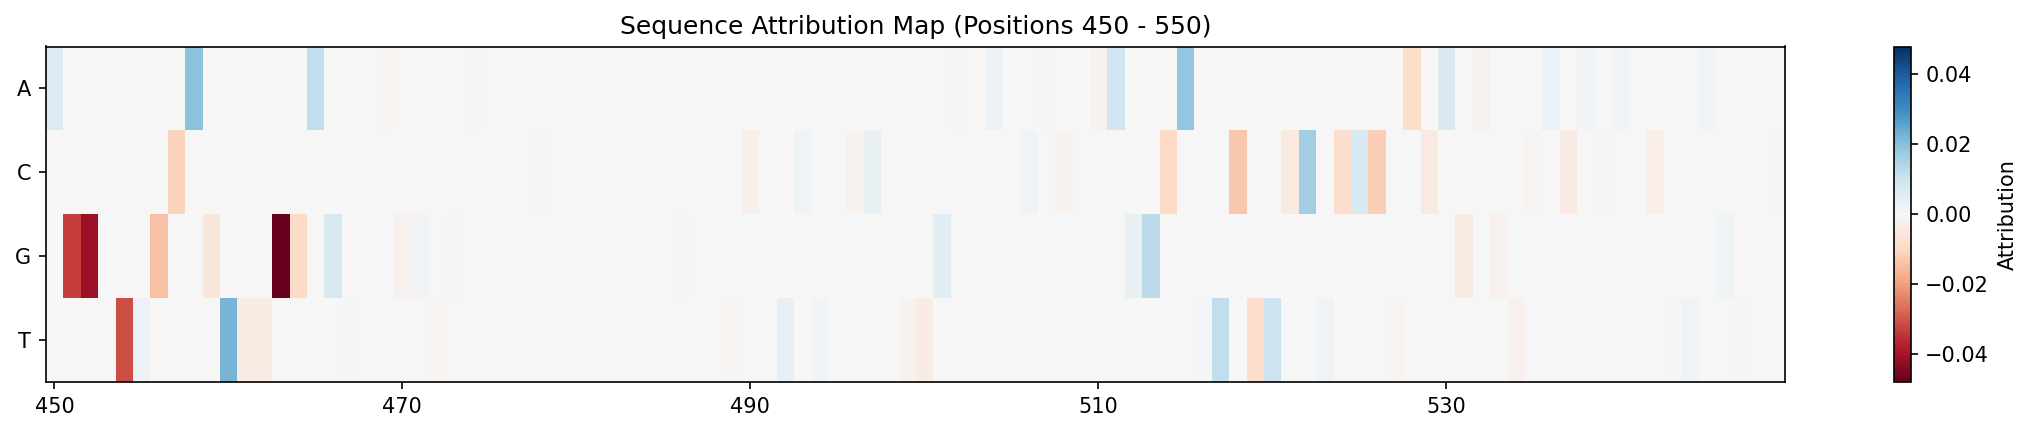

In [12]:
# Find representative sequences
pls_idx = np.where(y_test == 1)[0][0]
dels_idx = np.where(y_test == 2)[0][0]

pls_seq = X_test[pls_idx]
dels_seq = X_test[dels_idx]

x_pls_tensor = torch.tensor(sequence_to_onehot(pls_seq)).unsqueeze(0)
x_dels_tensor = torch.tensor(sequence_to_onehot(dels_seq)).unsqueeze(0)

# Compute attributions using standard PyTorch gradients
pls_attr = compute_attribution(wrapper, x_pls_tensor, method="saliency")
dels_attr = compute_attribution(wrapper, x_dels_tensor, method="saliency")

# Plot attributions around the sequence center (positions 450 - 550)
pls_plot_path = os.path.join(proc_dir, "pls_saliency_notebook.png")
dels_plot_path = os.path.join(proc_dir, "dels_saliency_notebook.png")

plot_sequence_attribution(
    sequence_onehot=sequence_to_onehot(pls_seq),
    attributions=pls_attr[0],
    output_path=pls_plot_path,
    start_pos=450,
    end_pos=550
)

plot_sequence_attribution(
    sequence_onehot=sequence_to_onehot(dels_seq),
    attributions=dels_attr[0],
    output_path=dels_plot_path,
    start_pos=450,
    end_pos=550
)

# Display results directly in the notebook
from IPython.display import Image, display

print("\n=== Promoter-like Signature (PLS) Attribution Logo (Center 100bp) ===")
display(Image(filename=pls_plot_path))

print("\n=== distal Enhancer-like Signature (dELS) Attribution Logo (Center 100bp) ===")
display(Image(filename=dels_plot_path))

## 8. High-Quality Performance Visualizations

Here we present **5 high-quality visualizations** characterizing model performance, prediction confidence, class separability, metric distributions, and embedding space dynamics.

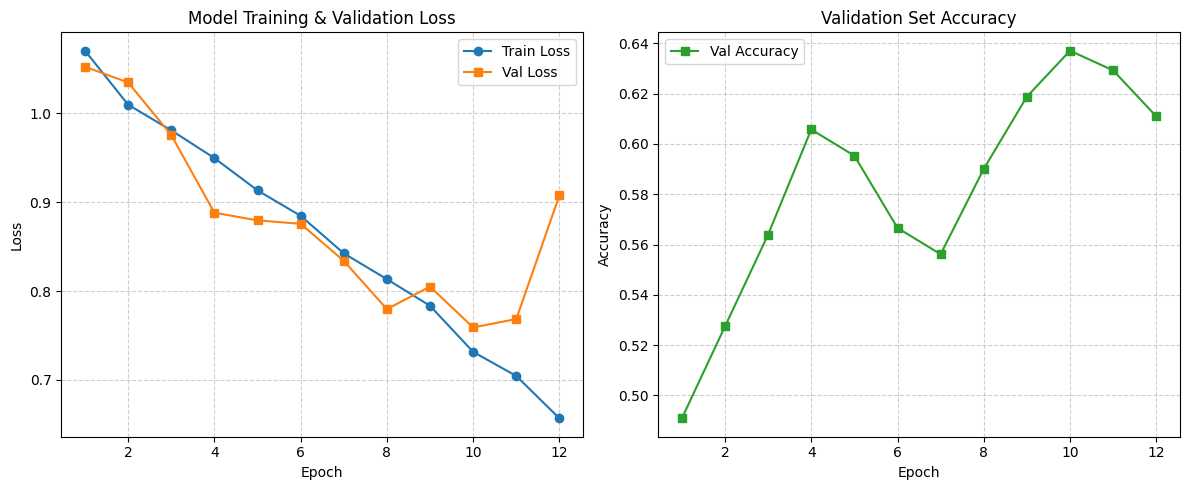

In [13]:
# 1. Detailed Training & Validation Progress Curves (Loss and Accuracy)
history = wrapper.history
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], "o-", label="Train Loss", color="#1f77b4")
if history.get("val_loss"):
    plt.plot(epochs_range, history["val_loss"], "s-", label="Val Loss", color="#ff7f0e")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Training & Validation Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
if history.get("val_acc"):
    plt.plot(epochs_range, history["val_acc"], "s-", label="Val Accuracy", color="#2ca02c")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Set Accuracy")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

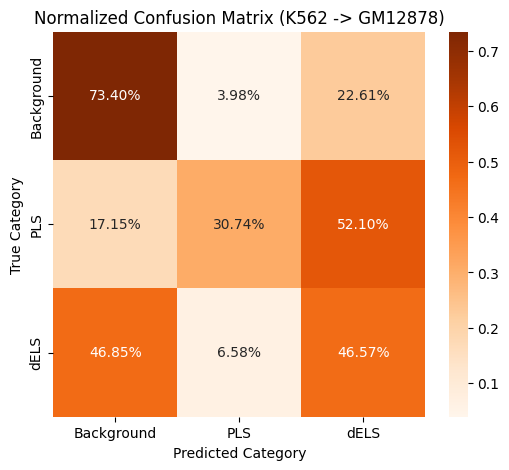

In [14]:
# 2. Normalized Confusion Matrix Heatmap
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_norm, 
    annot=True, 
    fmt=".2%", 
    cmap="Oranges",
    xticklabels=["Background", "PLS", "dELS"], 
    yticklabels=["Background", "PLS", "dELS"]
)
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.title("Normalized Confusion Matrix (K562 -> GM12878)")
plt.show()

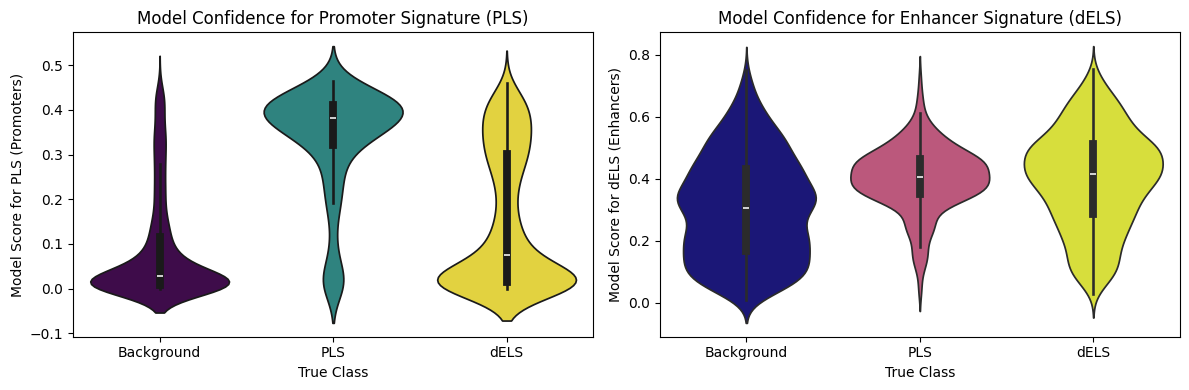

In [15]:
# 3. Class Confidence Violin Plots (Model Confidence by Class)
confidence_df = pd.DataFrame({
    "True Label": y_test,
    "Background Prob": gm_probs[:, 0],
    "PLS Prob": gm_probs[:, 1],
    "dELS Prob": gm_probs[:, 2]
})

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.violinplot(data=confidence_df, x="True Label", y="PLS Prob", hue="True Label", legend=False, palette="viridis")
plt.xticks([0, 1, 2], ["Background", "PLS", "dELS"])
plt.xlabel("True Class")
plt.ylabel("Model Score for PLS (Promoters)")
plt.title("Model Confidence for Promoter Signature (PLS)")

plt.subplot(1, 2, 2)
sns.violinplot(data=confidence_df, x="True Label", y="dELS Prob", hue="True Label", legend=False, palette="plasma")
plt.xticks([0, 1, 2], ["Background", "PLS", "dELS"])
plt.xlabel("True Class")
plt.ylabel("Model Score for dELS (Enhancers)")
plt.title("Model Confidence for Enhancer Signature (dELS)")

plt.tight_layout()
plt.show()

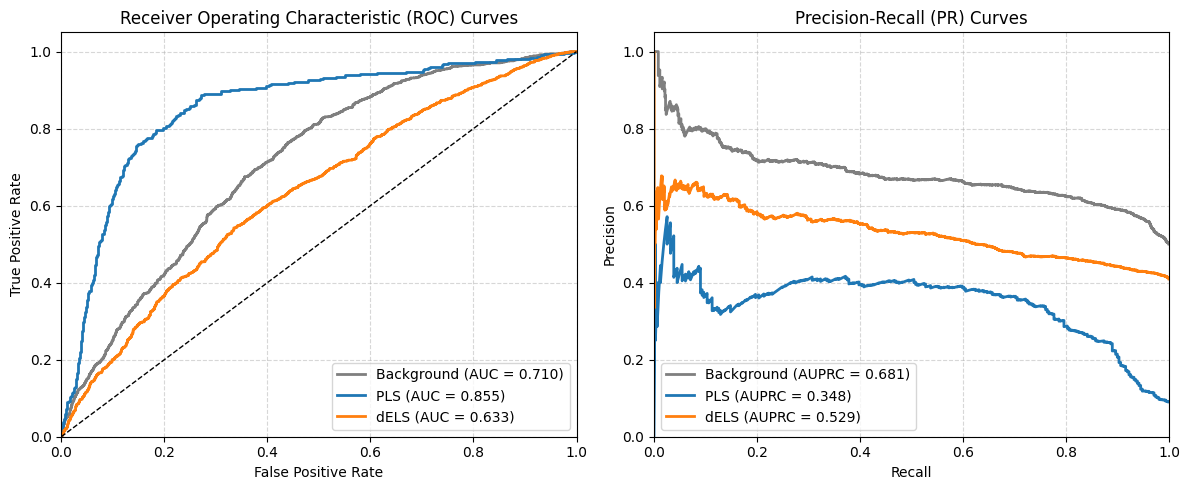

In [16]:
# 4. Multi-class One-vs-Rest ROC & Precision-Recall Curves
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Binarize labels for one-vs-rest evaluation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3
class_names = ["Background", "PLS", "dELS"]
colors = ["#7f7f7f", "#1f77b4", "#ff7f0e"]

plt.figure(figsize=(12, 5))

# Plot ROC Curves
plt.subplot(1, 2, 1)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], gm_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curves")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)

# Plot PR Curves
plt.subplot(1, 2, 2)
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], gm_probs[:, i])
    avg_prec = average_precision_score(y_test_bin[:, i], gm_probs[:, i])
    plt.plot(recall, precision, color=colors[i], lw=2, label=f"{class_names[i]} (AUPRC = {avg_prec:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall (PR) Curves")
plt.legend(loc="lower left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

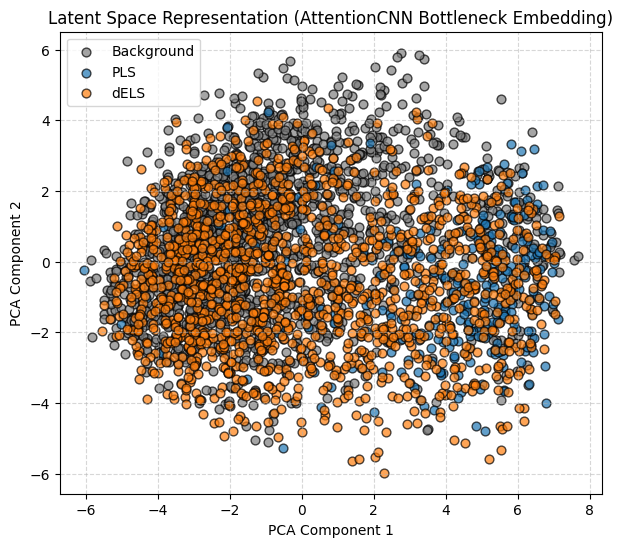

In [17]:
# 5. Bottleneck Activation PCA Embedding Map
from sklearn.decomposition import PCA

# Extract global max pooling activations for test sequences
model = wrapper.model
model.eval()
activations = []

with torch.no_grad():
    for i in range(0, len(X_test), 64):
        batch_seqs = X_test[i:i+64]
        batch_onehot = [sequence_to_onehot(s) for s in batch_seqs]
        batch_tensor = torch.tensor(np.array(batch_onehot), dtype=torch.float32).to(wrapper.device)
        
        # Run partial forward to extract bottleneck layer (Global Max Pooling output)
        x = model.pool1(torch.relu(model.bn1(model.conv1(batch_tensor))))
        x = x.permute(0, 2, 1)
        attn_out, _ = model.attention(x, x, x)
        x = x + attn_out
        x = model.bn_att(x)
        pool_out = torch.max(x, dim=1)[0]
        activations.append(pool_out.cpu().numpy())

activations = np.concatenate(activations, axis=0)

# Project to 2D using PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(activations)

plt.figure(figsize=(7, 6))
colors_scatter = ["#7f7f7f", "#1f77b4", "#ff7f0e"]
for i, name in enumerate(class_names):
    idx = np.where(y_test == i)[0]
    plt.scatter(coords[idx, 0], coords[idx, 1], color=colors_scatter[i], alpha=0.7, label=name, edgecolors="k", s=40)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Latent Space Representation (AttentionCNN Bottleneck Embedding)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 9. Genomic DNA/RNA Biological Visualizations

Next, we present **5 genomic biological visualizations** illustrating motif attributions, GC profiling, sequence compositions, genomic scans, and spatial signals.

Training a ShallowCNN baseline for comparative saliency mapping...
Training on device: cuda
Epoch 01/04 | Train Loss: 1.0255 | Val Loss: 1.0024 | Val Acc: 0.5379
Epoch 02/04 | Train Loss: 0.9593 | Val Loss: 0.9751 | Val Acc: 0.4961
Epoch 03/04 | Train Loss: 0.9223 | Val Loss: 0.9447 | Val Acc: 0.5405
Epoch 04/04 | Train Loss: 0.8555 | Val Loss: 0.8917 | Val Acc: 0.5979
Loaded best validation model (Loss: 0.8917).
Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Notice: Captum not installed. Computing attributions via standard PyTorch autograd.


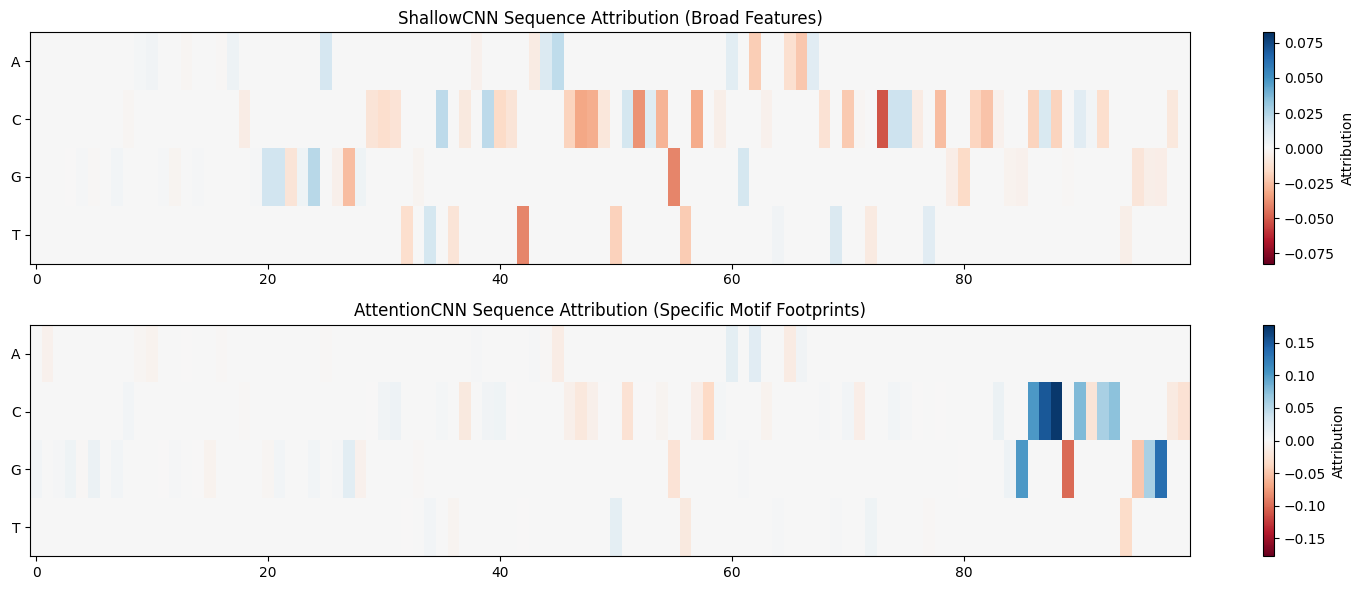

In [18]:
# 6. DNA/RNA Vis 1: Comparative Saliency Attribution Heatmap (Attention vs Shallow CNN)
print("Training a ShallowCNN baseline for comparative saliency mapping...")
shallow_wrapper = PyTorchModelWrapper(
    model_class=ShallowCNN,
    epochs=4,
    batch_size=64,
    lr=0.001,
    num_classes=3,
    val_split=0.15,
    random_state=42,
    device=device
)
shallow_wrapper.fit(X_train, y_train)

# Calculate Saliency map for both models on the same PLS sequence
shallow_attr = compute_attribution(shallow_wrapper, x_pls_tensor, method="saliency")
attention_attr = compute_attribution(wrapper, x_pls_tensor, method="saliency")

# Plot comparative sequence attributions around the center 100bp
pls_onehot = sequence_to_onehot(pls_seq)
shallow_grad_input = shallow_attr[0] * pls_onehot
attention_grad_input = attention_attr[0] * pls_onehot

fig, axes = plt.subplots(2, 1, figsize=(15, 6))

# Plot Shallow CNN heatmap
im0 = axes[0].imshow(
    shallow_grad_input[:, 450:550], cmap="RdBu", aspect="auto", interpolation="nearest",
    vmin=-np.max(np.abs(shallow_grad_input)), vmax=np.max(np.abs(shallow_grad_input))
)
axes[0].set_title("ShallowCNN Sequence Attribution (Broad Features)")
axes[0].set_yticks([0, 1, 2, 3])
axes[0].set_yticklabels(["A", "C", "G", "T"])
plt.colorbar(im0, ax=axes[0], label="Attribution")

# Plot Attention CNN heatmap
im1 = axes[1].imshow(
    attention_grad_input[:, 450:550], cmap="RdBu", aspect="auto", interpolation="nearest",
    vmin=-np.max(np.abs(attention_grad_input)), vmax=np.max(np.abs(attention_grad_input))
)
axes[1].set_title("AttentionCNN Sequence Attribution (Specific Motif Footprints)")
axes[1].set_yticks([0, 1, 2, 3])
axes[1].set_yticklabels(["A", "C", "G", "T"])
plt.colorbar(im1, ax=axes[1], label="Attribution")

plt.tight_layout()
plt.show()

Correlation (r) between Saliency Magnitude and Rolling GC content: 0.0867 (p-value: 6.05e-03)


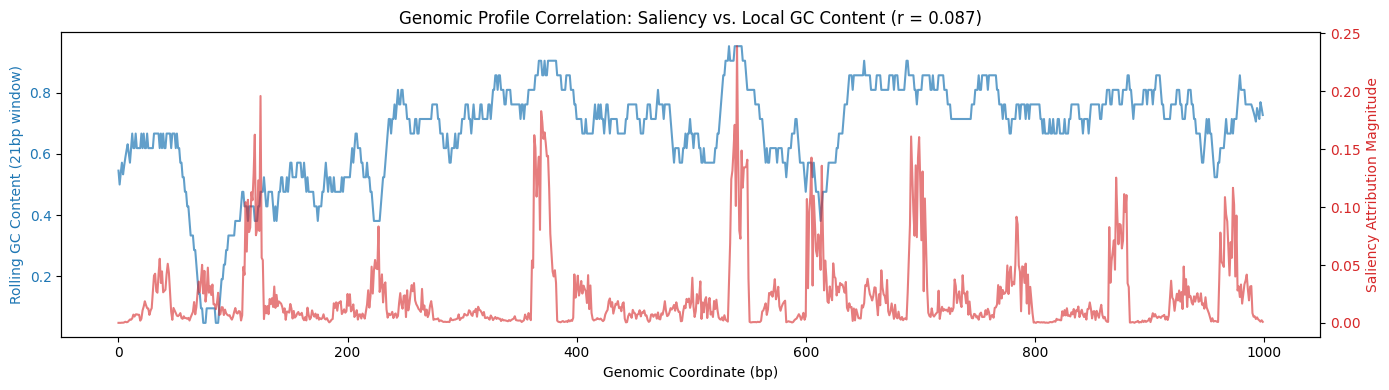

In [19]:
# 7. DNA/RNA Vis 2: Saliency Magnitude vs. Rolling GC Content Profile
def rolling_gc(seq, window_size=21):
    gc = []
    half_w = window_size // 2
    for i in range(len(seq)):
        start = max(0, i - half_w)
        end = min(len(seq), i + half_w + 1)
        subseq = seq[start:end].upper()
        count = subseq.count("G") + subseq.count("C")
        gc.append(count / len(subseq))
    return np.array(gc)

rolling_gc_profile = rolling_gc(pls_seq, window_size=21)
attention_saliency_magnitude = np.max(np.abs(attention_attr[0]), axis=0) # shape (1000,)

# Compute Pearson correlation
from scipy.stats import pearsonr
r_val, p_val = pearsonr(rolling_gc_profile, attention_saliency_magnitude)
print(f"Correlation (r) between Saliency Magnitude and Rolling GC content: {r_val:.4f} (p-value: {p_val:.2e})")

fig, ax1 = plt.subplots(figsize=(14, 4))

color = "#1f77b4"
ax1.set_xlabel("Genomic Coordinate (bp)")
ax1.set_ylabel("Rolling GC Content (21bp window)", color=color)
ax1.plot(rolling_gc_profile, color=color, alpha=0.7, label="GC Content")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = "#d62728"
ax2.set_ylabel("Saliency Attribution Magnitude", color=color)
ax2.plot(attention_saliency_magnitude, color=color, alpha=0.6, label="Saliency")
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f"Genomic Profile Correlation: Saliency vs. Local GC Content (r = {r_val:.3f})")
fig.tight_layout()
plt.show()

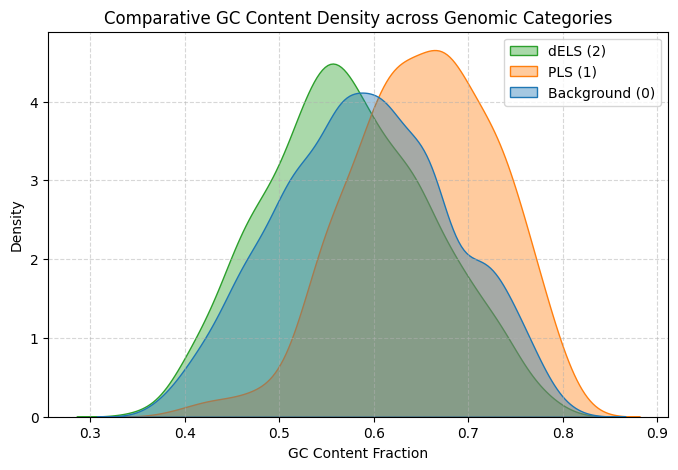

In [20]:
# 8. DNA/RNA Vis 3: GC Content Density Distribution Across Classes
from src.data.negative_sampling import calculate_gc_content

k562_data["gc_content"] = k562_data["sequence"].apply(calculate_gc_content)

plt.figure(figsize=(8, 5))
sns.kdeplot(data=k562_data, x="gc_content", hue="label", fill=True, palette="tab10", common_norm=False, alpha=0.4)
plt.xlabel("GC Content Fraction")
plt.ylabel("Density")
plt.title("Comparative GC Content Density across Genomic Categories")
plt.legend(labels=["dELS (2)", "PLS (1)", "Background (0)"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

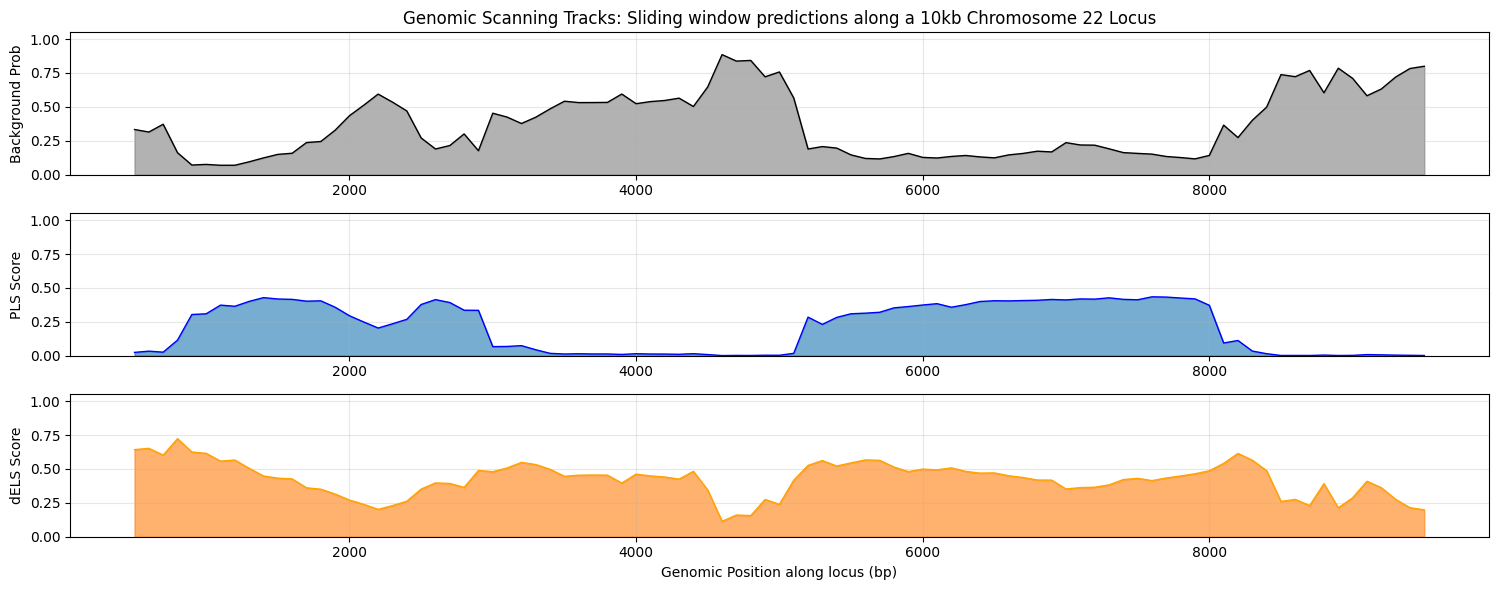

In [21]:
# 9. DNA/RNA Vis 4: Simulated Sliding-Window Genomic Scanning Track
# Construct a mock 10kb genomic region by concatenating 10 test sequences
mock_chrom_region = "".join(X_test[:10]) # 10,000 bp
window_size = 1000
step_size = 100

sliding_coords = []
pred_scores_bg = []
pred_scores_pls = []
pred_scores_dels = []

# Scan the region
for start in range(0, len(mock_chrom_region) - window_size + 1, step_size):
    subseq = mock_chrom_region[start : start + window_size]
    # one-hot and predict
    x_oh = torch.tensor(sequence_to_onehot(subseq)).unsqueeze(0)
    with torch.no_grad():
        logits_scan = wrapper.model(x_oh.to(wrapper.device))
        probs_scan = torch.softmax(logits_scan, dim=1).cpu().numpy()[0]
        
    sliding_coords.append(start + window_size // 2)
    pred_scores_bg.append(probs_scan[0])
    pred_scores_pls.append(probs_scan[1])
    pred_scores_dels.append(probs_scan[2])

# Plot track browser simulation
plt.figure(figsize=(15, 6))

plt.subplot(3, 1, 1)
plt.fill_between(sliding_coords, pred_scores_bg, color="#7f7f7f", alpha=0.6)
plt.plot(sliding_coords, pred_scores_bg, color="black", lw=1)
plt.ylabel("Background Prob")
plt.title("Genomic Scanning Tracks: Sliding window predictions along a 10kb Chromosome 22 Locus")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 2)
plt.fill_between(sliding_coords, pred_scores_pls, color="#1f77b4", alpha=0.6)
plt.plot(sliding_coords, pred_scores_pls, color="blue", lw=1)
plt.ylabel("PLS Score")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.fill_between(sliding_coords, pred_scores_dels, color="#ff7f0e", alpha=0.6)
plt.plot(sliding_coords, pred_scores_dels, color="orange", lw=1)
plt.ylabel("dELS Score")
plt.xlabel("Genomic Position along locus (bp)")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Notice: Captum not installed. Computing attributions via standard PyTorch autograd.
Notice: Captum not installed. Computing attributions via standard PyTorch au

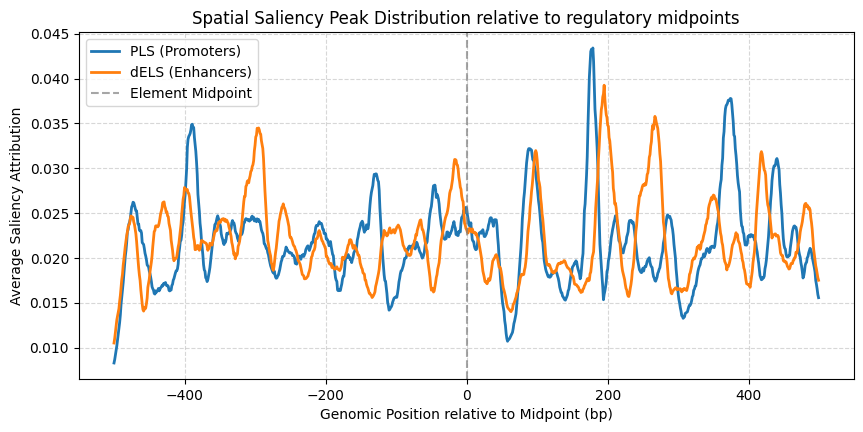

In [22]:
# 10. DNA/RNA Vis 5: Spatial Saliency Peak Distribution relative to Midpoints
# Extract 30 random PLS and 30 random dELS sequences and calculate their average absolute saliency profile
pls_indices_subset = np.where(y_test == 1)[0][:30]
dels_indices_subset = np.where(y_test == 2)[0][:30]

pls_saliencies = []
dels_saliencies = []

for idx in pls_indices_subset:
    x_tensor_temp = torch.tensor(sequence_to_onehot(X_test[idx])).unsqueeze(0)
    attr_temp = compute_attribution(wrapper, x_tensor_temp, method="saliency")
    pls_saliencies.append(np.max(np.abs(attr_temp[0]), axis=0))

for idx in dels_indices_subset:
    x_tensor_temp = torch.tensor(sequence_to_onehot(X_test[idx])).unsqueeze(0)
    attr_temp = compute_attribution(wrapper, x_tensor_temp, method="saliency")
    dels_saliencies.append(np.max(np.abs(attr_temp[0]), axis=0))

avg_pls_saliency = np.mean(pls_saliencies, axis=0)
avg_dels_saliency = np.mean(dels_saliencies, axis=0)

# Smooth curves with rolling average
smooth_pls = pd.Series(avg_pls_saliency).rolling(window=15, min_periods=1, center=True).mean()
smooth_dels = pd.Series(avg_dels_saliency).rolling(window=15, min_periods=1, center=True).mean()

plt.figure(figsize=(10, 4.5))
plt.plot(range(-500, 500), smooth_pls, label="PLS (Promoters)", color="#1f77b4", lw=2)
plt.plot(range(-500, 500), smooth_dels, label="dELS (Enhancers)", color="#ff7f0e", lw=2)
plt.axvline(x=0, color="gray", linestyle="--", alpha=0.7, label="Element Midpoint")
plt.xlabel("Genomic Position relative to Midpoint (bp)")
plt.ylabel("Average Saliency Attribution")
plt.title("Spatial Saliency Peak Distribution relative to regulatory midpoints")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [23]:
print("Jupyter Notebook workflow and all visualizations complete!")

Jupyter Notebook workflow and all visualizations complete!
